# Tree vs No-Tree Analysis

This notebook provides a focused analysis comparing the performance of tree-based vs non-tree-based configurations in the MMLLM benchmarking framework.

## Overview

We will specifically analyze:
1. **Performance Comparison**: Direct comparison between tree and no-tree configurations
2. **Decision Tree Impact**: How tree structure affects different types of tasks
3. **Efficiency Analysis**: Speed vs accuracy trade-offs
4. **Dataset-Specific Effects**: Which datasets benefit most from tree structures

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Load data from tree vs no-tree experiments
RESULTS_PATH = Path("../results/tree-vs-no-tree")
print(f"Tree analysis path: {RESULTS_PATH.absolute()}")
print(f"Path exists: {RESULTS_PATH.exists()}")

# Load tree and no-tree data
tree_csv = RESULTS_PATH / "tree" / "benchmark_results_20250720_130945.csv"
no_tree_csv = RESULTS_PATH / "no-tree" / "benchmark_results_20250720_130908.csv"

tree_json = RESULTS_PATH / "tree" / "benchmark_report_20250720_130945.json"
no_tree_json = RESULTS_PATH / "no-tree" / "benchmark_report_20250720_130908.json"

# Check file existence
print(f"Tree CSV exists: {tree_csv.exists()}")
print(f"No-tree CSV exists: {no_tree_csv.exists()}")
print(f"Tree JSON exists: {tree_json.exists()}")
print(f"No-tree JSON exists: {no_tree_json.exists()}")

# Load the data
tree_data = pd.read_csv(tree_csv) if tree_csv.exists() else pd.DataFrame()
no_tree_data = pd.read_csv(no_tree_csv) if no_tree_csv.exists() else pd.DataFrame()

tree_data['config'] = 'tree'
no_tree_data['config'] = 'no-tree'

combined_tree_data = pd.concat([tree_data, no_tree_data], ignore_index=True)

print(f"Tree data shape: {tree_data.shape}")
print(f"No-tree data shape: {no_tree_data.shape}")
print(f"Combined data shape: {combined_tree_data.shape}")

Tree analysis path: /home/kiko/mmllm/vis/../results/tree-vs-no-tree
Path exists: True
Tree CSV exists: True
No-tree CSV exists: True
Tree JSON exists: True
No-tree JSON exists: True
Tree data shape: (235, 39)
No-tree data shape: (237, 39)
Combined data shape: (472, 39)


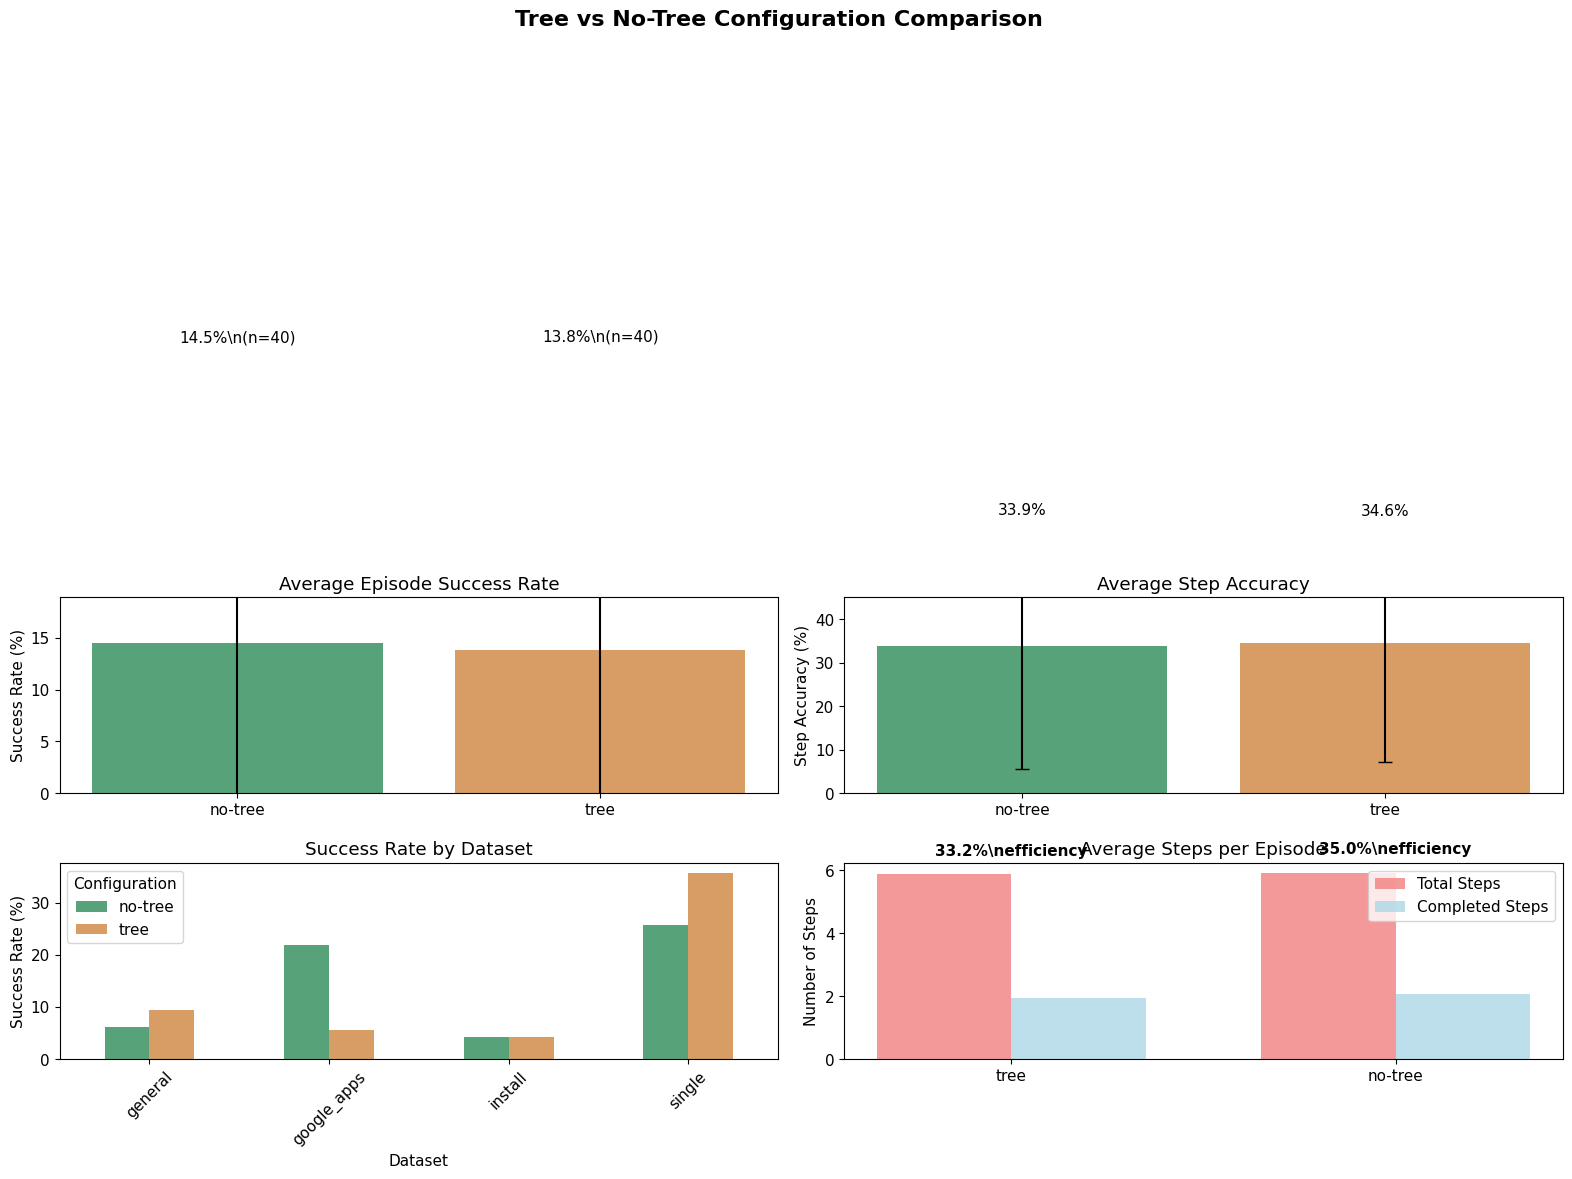

\n============================================================
TREE VS NO-TREE DETAILED COMPARISON
\nTREE Configuration:
  Episodes analyzed: 40
  Average success rate: 13.80% (±27.54)
  Average step accuracy: 34.63% (±27.46)
  Average total steps: 5.9 (±3.5)
  Average completed steps: 1.9 (±1.6)
  Dataset performance:
    google_apps: 5.7% (n=10)
    general: 9.4% (n=10)
    install: 4.2% (n=10)
    single: 35.8% (n=10)
\nNO-TREE Configuration:
  Episodes analyzed: 40
  Average success rate: 14.53% (±26.69)
  Average step accuracy: 33.88% (±28.40)
  Average total steps: 5.9 (±3.5)
  Average completed steps: 2.1 (±1.8)
  Dataset performance:
    google_apps: 21.9% (n=10)
    general: 6.1% (n=10)
    install: 4.2% (n=10)
    single: 25.8% (n=10)


In [2]:
# Create comprehensive tree vs no-tree comparison
if not combined_tree_data.empty:
    
    # Calculate episode-level metrics
    episode_metrics = combined_tree_data.groupby(['config', 'episode_id']).agg({
        'episode_success_rate': 'first',
        'episode_step_accuracy': 'first',
        'episode_total_steps': 'first',
        'episode_steps_completed': 'first',
        'dataset_name': 'first'
    }).reset_index()
    
    # Create comparison visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Tree vs No-Tree Configuration Comparison', fontsize=16, fontweight='bold')
    
    # 1. Success Rate Comparison
    ax1 = axes[0, 0]
    success_comparison = episode_metrics.groupby('config')['episode_success_rate'].agg(['mean', 'std', 'count'])
    
    bars = ax1.bar(success_comparison.index, success_comparison['mean'], 
                   yerr=success_comparison['std'], capsize=5,
                   color=['#2E8B57', '#CD853F'], alpha=0.8)
    ax1.set_title('Average Episode Success Rate')
    ax1.set_ylabel('Success Rate (%)')
    ax1.set_ylim(0, max(success_comparison['mean']) * 1.3)
    
    # Add value labels and sample sizes
    for i, (bar, count) in enumerate(zip(bars, success_comparison['count'])):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + success_comparison['std'].iloc[i] + 2,
                f'{height:.1f}%\\n(n={count})', ha='center', va='bottom')
    
    # 2. Step Accuracy Comparison  
    ax2 = axes[0, 1]
    accuracy_comparison = episode_metrics.groupby('config')['episode_step_accuracy'].agg(['mean', 'std'])
    
    bars = ax2.bar(accuracy_comparison.index, accuracy_comparison['mean'],
                   yerr=accuracy_comparison['std'], capsize=5,
                   color=['#2E8B57', '#CD853F'], alpha=0.8)
    ax2.set_title('Average Step Accuracy')
    ax2.set_ylabel('Step Accuracy (%)')
    ax2.set_ylim(0, max(accuracy_comparison['mean']) * 1.3)
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + accuracy_comparison['std'].iloc[i] + 1,
                f'{height:.1f}%', ha='center', va='bottom')
    
    # 3. Performance by Dataset
    ax3 = axes[1, 0]
    dataset_performance = episode_metrics.groupby(['dataset_name', 'config'])['episode_success_rate'].mean().unstack(fill_value=0)
    
    dataset_performance.plot(kind='bar', ax=ax3, color=['#2E8B57', '#CD853F'], alpha=0.8)
    ax3.set_title('Success Rate by Dataset')
    ax3.set_ylabel('Success Rate (%)')
    ax3.set_xlabel('Dataset')
    ax3.legend(title='Configuration')
    ax3.tick_params(axis='x', rotation=45)
    
    # 4. Efficiency Analysis (Steps)
    ax4 = axes[1, 1]
    
    # Calculate efficiency metrics
    efficiency_data = []
    for config in ['tree', 'no-tree']:
        config_data = episode_metrics[episode_metrics['config'] == config]
        avg_total_steps = config_data['episode_total_steps'].mean()
        avg_completed_steps = config_data['episode_steps_completed'].mean()
        completion_rate = (avg_completed_steps / avg_total_steps) * 100 if avg_total_steps > 0 else 0
        
        efficiency_data.append({
            'config': config,
            'avg_total_steps': avg_total_steps,
            'avg_completed_steps': avg_completed_steps,
            'completion_rate': completion_rate
        })
    
    efficiency_df = pd.DataFrame(efficiency_data)
    
    x_pos = np.arange(len(efficiency_df))
    width = 0.35
    
    bars1 = ax4.bar(x_pos - width/2, efficiency_df['avg_total_steps'], width,
                   label='Total Steps', alpha=0.8, color='lightcoral')
    bars2 = ax4.bar(x_pos + width/2, efficiency_df['avg_completed_steps'], width,
                   label='Completed Steps', alpha=0.8, color='lightblue')
    
    ax4.set_title('Average Steps per Episode')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(efficiency_df['config'])
    ax4.set_ylabel('Number of Steps')
    ax4.legend()
    
    # Add efficiency percentages
    for i, (total, completed) in enumerate(zip(efficiency_df['avg_total_steps'], efficiency_df['avg_completed_steps'])):
        efficiency = (completed / total) * 100 if total > 0 else 0
        ax4.text(i, max(total, completed) + 0.5, f'{efficiency:.1f}%\\nefficiency', 
                ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\\n" + "="*60)
    print("TREE VS NO-TREE DETAILED COMPARISON")
    print("="*60)
    
    for config in ['tree', 'no-tree']:
        config_data = episode_metrics[episode_metrics['config'] == config]
        print(f"\\n{config.upper()} Configuration:")
        print(f"  Episodes analyzed: {len(config_data)}")
        print(f"  Average success rate: {config_data['episode_success_rate'].mean():.2f}% (±{config_data['episode_success_rate'].std():.2f})")
        print(f"  Average step accuracy: {config_data['episode_step_accuracy'].mean():.2f}% (±{config_data['episode_step_accuracy'].std():.2f})")
        print(f"  Average total steps: {config_data['episode_total_steps'].mean():.1f} (±{config_data['episode_total_steps'].std():.1f})")
        print(f"  Average completed steps: {config_data['episode_steps_completed'].mean():.1f} (±{config_data['episode_steps_completed'].std():.1f})")
        
        # Dataset breakdown
        print(f"  Dataset performance:")
        for dataset in config_data['dataset_name'].unique():
            dataset_perf = config_data[config_data['dataset_name'] == dataset]['episode_success_rate'].mean()
            dataset_count = len(config_data[config_data['dataset_name'] == dataset])
            print(f"    {dataset}: {dataset_perf:.1f}% (n={dataset_count})")

else:
    print("No tree vs no-tree data available!")